## Importando Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Leitura da Base de Dados

In [2]:
dados = pd.read_csv("../data/data_energy.csv")
dados.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


## Padronização das variáveis

In [3]:
dados.columns = ["data_hora", "temperatura", "umidade", "velocidade_vento", "fluxo_difuso_geral",
                 "fluxo_difuso", "consumo_zona_1", "consumo_zona_2", "consumo_zona_3"]
dados.columns.tolist()

['data_hora',
 'temperatura',
 'umidade',
 'velocidade_vento',
 'fluxo_difuso_geral',
 'fluxo_difuso',
 'consumo_zona_1',
 'consumo_zona_2',
 'consumo_zona_3']

## Entendimento da Base de Dados

In [6]:
print(f"Total Linhas -> {dados.shape[0]}")
print(f"Total Colunas -> {dados.shape[1]}")
print()
print(dados.info())

Total Linhas -> 52416
Total Colunas -> 9

<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_hora           52416 non-null  str    
 1   temperatura         52416 non-null  float64
 2   umidade             52416 non-null  float64
 3   velocidade_vento    52416 non-null  float64
 4   fluxo_difuso_geral  52416 non-null  float64
 5   fluxo_difuso        52416 non-null  float64
 6   consumo_zona_1      52416 non-null  float64
 7   consumo_zona_2      52416 non-null  float64
 8   consumo_zona_3      52416 non-null  float64
dtypes: float64(8), str(1)
memory usage: 3.6 MB
None


In [7]:
print("=== Dados Nulos ===")
print(dados.isna().sum())

=== Dados Nulos ===
data_hora             0
temperatura           0
umidade               0
velocidade_vento      0
fluxo_difuso_geral    0
fluxo_difuso          0
consumo_zona_1        0
consumo_zona_2        0
consumo_zona_3        0
dtype: int64


In [10]:
print(f"Total de Dados Duplicados: {dados.duplicated().sum()}")

Total de Dados Duplicados: 0


In [14]:
dados.describe().round(3)

,temperatura,umidade,velocidade_vento,fluxo_difuso_geral,fluxo_difuso,consumo_zona_1,consumo_zona_2,consumo_zona_3
count,52416.000,52416.000,52416.000,52416.000,52416.000,52416.000,52416.000,52416.000
mean,18.810,68.260,1.959,182.697,75.028,32344.971,21042.509,17835.406
std,5.815,15.551,2.349,264.401,124.211,7130.563,5201.466,6622.165
min,3.247,11.340,0.050,0.004,0.011,13895.696,8560.081,5935.174
25%,14.410,58.310,0.078,0.062,0.122,26310.669,16980.766,13129.327
50%,18.780,69.860,0.086,5.036,4.456,32265.920,20823.168,16415.117
75%,22.890,81.400,4.915,319.600,101.000,37309.018,24713.718,21624.100
max,40.010,94.800,6.483,1163.000,936.000,52204.395,37408.861,47598.326


## Arrumando o DateTime

In [11]:
# Conversão da variável temporal
dados["data_hora"] = pd.to_datetime(dados["data_hora"], format="%m/%d/%Y %H:%M")

# Ordenação cronológica
dados = dados.sort_values("data_hora")

# Definição do índice do dataset
dados = dados.set_index("data_hora")

In [13]:
# Validações
print(f"índice ordenado: {dados.index.is_monotonic_increasing}")
print(f"Datas Duplicadas: {dados.index.duplicated().sum()}")
print(f"Frequência: {pd.infer_freq(dados.index)}")

índice ordenado: True
Datas Duplicadas: 0
Frequência: 10min


## Análise Gráfica da Série

In [18]:
print(f"Período -> {dados.index.min().date()} até {dados.index.max().date()}")

Período -> 2017-01-01 até 2017-12-30


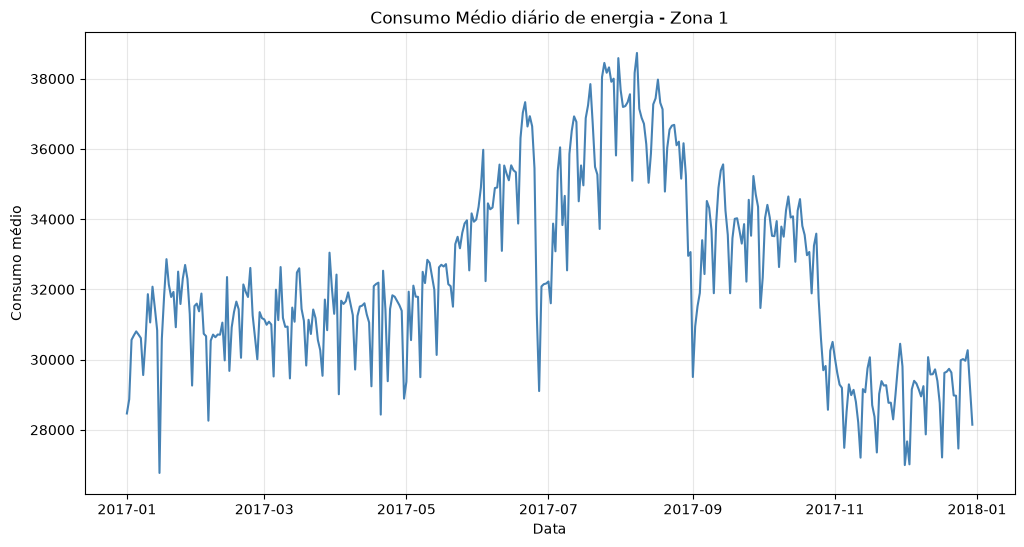

In [19]:
# Agregando a série por dia
consumo_diario = dados["consumo_zona_1"].resample("D").mean()

plt.figure(figsize=(12,6))

plt.plot(consumo_diario.index, consumo_diario, color="steelblue")
plt.title("Consumo Médio diário de energia - Zona 1")
plt.xlabel("Data")
plt.ylabel("Consumo médio")
plt.grid(alpha=0.3)
plt.show()

## Salvando os Dados

In [20]:
dados.to_csv("../data/dados_tratados.csv", index=True)